# Explainable AI for Sleep Staging with PhysioEx

**UGent — Explainable & Trustworthy AI** | Use Cases Session  
**June 24, 2026** — Guido Gagliardi, ESAT-STADIUS, KU Leuven

---

[PhysioEx](https://github.com/guidogagl/physioex) is an open-source Python library for **training, evaluating, and explaining** deep learning models on physiological signals (sleep staging from EEG).

In [1]:
# Install from PyPI
# !pip install physioex

# Or install from source (latest dev version)
# !git clone https://github.com/guidogagl/physioex.git
# !pip install -e ./physioex

import torch
import numpy as np
import matplotlib.pyplot as plt

from util import (
    STAGE_NAMES, STAGE_COLORS,
    plot_hypnogram, plot_epoch_with_psd, plot_spectrogram_with_psd,
    plot_pred_barplot, plot_ig_raw, plot_ig_spectrogram,
    plot_attribution_vs_psd,
)

device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda:0


## The Problem

**Sleep staging** = classifying every 30-second segment (epoch) of an overnight EEG recording into one of 5 stages:

| Stage | What it looks like | Key frequency |
|-------|-------------------|---------------|
| **W** (Wake) | Alpha rhythm, eye blinks | 8–13 Hz |
| **N1** (Light) | Theta waves | 4–8 Hz |
| **N2** (Stable) | Sleep spindles, K-complexes | 11–16 Hz |
| **N3** (Deep) | Slow delta waves | 0.5–4 Hz |
| **REM** (Dream) | Low-voltage mixed, eye movements | Mixed |

A clinician scores ~1000 epochs per night — tedious, slow, and only ~82% inter-rater agreement. Can we automate this with deep learning, and **explain** what the model sees?

## Data: Two Representations

Models can work on **raw waveforms** (time-domain) or **spectrograms** (time-frequency).  
For each, we'll look at an N3 (deep sleep) epoch and its **power spectrum** — to see which EEG frequency bands dominate before we even run a model.

In [2]:
from physioex.data.datasets import SleepEDFDataset, MASSDataset

# TinySleepNet's training data: Sleep-EDF, raw waveforms
ds_raw = SleepEDFDataset(
    channels=["EEG"],
    pipelines="raw",          # bandpass 0.3-40 Hz + resample to 100 Hz
    sequence_length=20,        # 20 consecutive 30-sec epochs (= 10 min)
)

print(f"Sleep-EDF: {ds_raw.get_n_subjects()} subjects, {len(ds_raw)} sequences")

# Find a sample with N3 epochs in mid-sequence
sample_raw = None
for i in range(0, min(20000, len(ds_raw))):
    s = ds_raw[i]
    labels = s["labels"]
    valid = labels[labels >= 0]
    n3_pos = (labels == 3).nonzero(as_tuple=True)[0]
    mid_n3 = [p.item() for p in n3_pos if 5 <= p.item() <= 15]
    if len(valid) >= 15 and len(valid.unique()) >= 3 and len(n3_pos) >= 3 and mid_n3:
        sample_raw = s
        print(f"Using sample index {i}, labels={labels.tolist()}")
        break

eeg_ch = sample_raw["channel_order"][0]
print(f"Channel: {eeg_ch}")
print(f"Signal shape: {sample_raw['signals'][eeg_ch].shape}  (L epochs x T samples)")

Sleep-EDF: 153 subjects, 437733 sequences
Using sample index 1023, labels=[1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 3, 3, 3]
Channel: EEG_0
Signal shape: torch.Size([20, 3000])  (L epochs x T samples)


Epoch 15: label = N3 (deep sleep)


/mnt/nfs/guido/home/dev/physioex/lectures/2026-06-24_ugent_xai/util.py:301: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


''

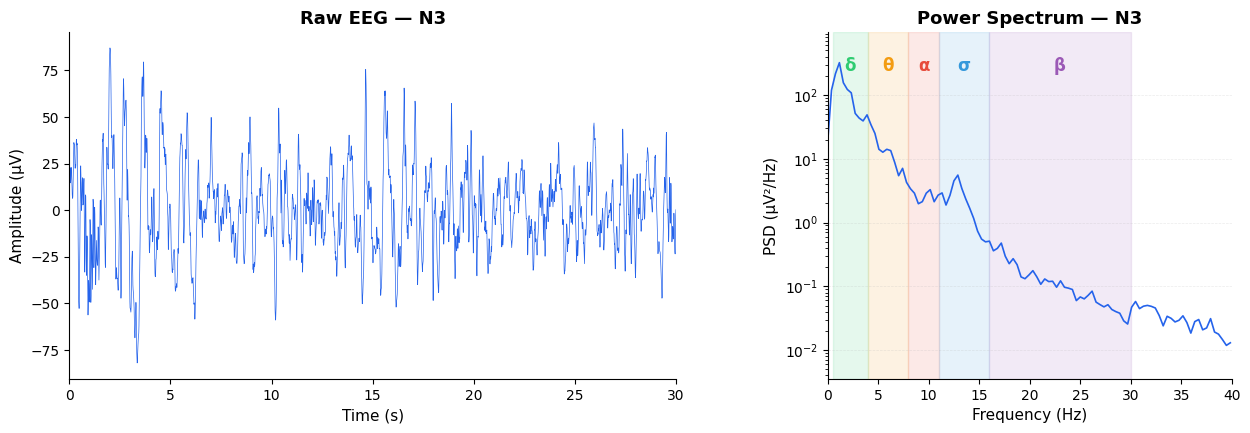

In [3]:
# Visualize an N3 epoch: raw waveform + power spectral density
n3_pos_raw = (sample_raw["labels"] == 3).nonzero(as_tuple=True)[0]
mid_n3_raw = [p.item() for p in n3_pos_raw if 5 <= p.item() <= 15]
vis_epoch_raw = mid_n3_raw[len(mid_n3_raw) // 2]

print(f"Epoch {vis_epoch_raw}: label = N3 (deep sleep)")
plot_epoch_with_psd(sample_raw["signals"][eeg_ch][vis_epoch_raw], fs=100, stage_name="N3")

_

In [4]:
# SeqSleepNet's training data: MASS SS03, spectrograms
ds_spec = MASSDataset(
    cohort=3,                  # SS03 (AASM-scored, 30-sec epochs)
    channels=["EEG"],
    pipelines="seqsleepnet",   # bandpass + resample + STFT spectrogram
    sequence_length=20,
)

print(f"MASS SS03: {ds_spec.get_n_subjects()} subjects, {len(ds_spec)} sequences")

# Find a sample with many N3 epochs (for high-confidence predictions)
sample_spec = None
for i in range(0, min(20000, len(ds_spec))):
    s = ds_spec[i]
    labels = s["labels"]
    valid = labels[labels >= 0]
    n3_count = (labels == 3).sum().item()
    if len(valid) >= 15 and len(valid.unique()) >= 3 and n3_count >= 5:
        sample_spec = s
        print(f"Using sample index {i}, labels={labels.tolist()}")
        break

eeg_ch_spec = sample_spec["channel_order"][0]
print(f"Channel: {eeg_ch_spec}")
print(f"Signal shape: {sample_spec['signals'][eeg_ch_spec].shape}  (L epochs x T time x F freq)")

MASS SS03: 62 subjects, 61743 sequences
Using sample index 65, labels=[3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 1]
Channel: EEG_0
Signal shape: torch.Size([20, 29, 129])  (L epochs x T time x F freq)


Epoch 9: label = N3 (deep sleep)


/mnt/nfs/guido/home/dev/physioex/lectures/2026-06-24_ugent_xai/util.py:351: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


''

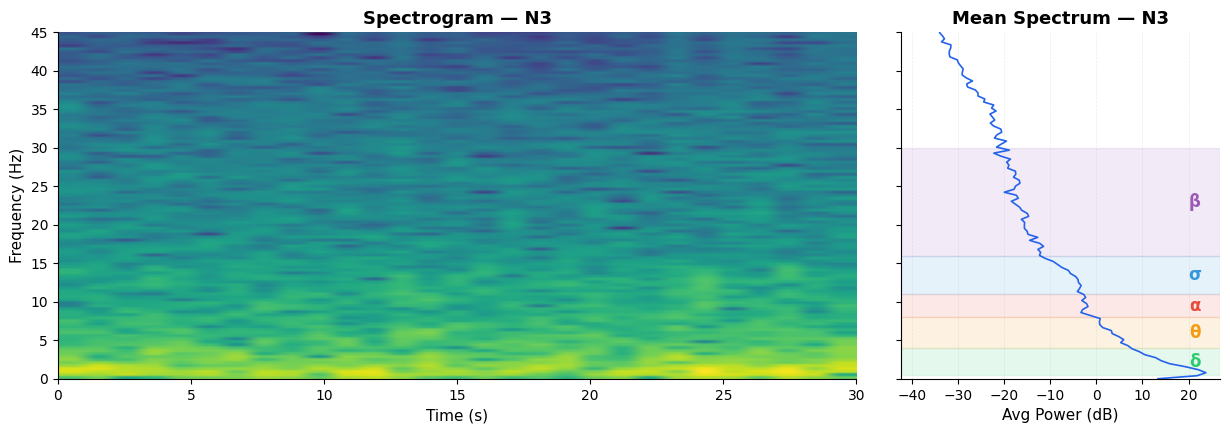

In [5]:
# Visualize an N3 epoch: spectrogram + time-averaged power spectrum
n3_pos_spec = (sample_spec["labels"] == 3).nonzero(as_tuple=True)[0]
vis_epoch_spec = n3_pos_spec[len(n3_pos_spec) // 2].item()

print(f"Epoch {vis_epoch_spec}: label = N3 (deep sleep)")
plot_spectrogram_with_psd(sample_spec["signals"][eeg_ch_spec][vis_epoch_spec], stage_name="N3")
_

### Takeaway

Both representations capture the same underlying physiology:
- **Raw waveform**: slow, high-amplitude oscillations visible in the time domain; the PSD confirms dominant **delta power (0.5–4 Hz)**
- **Spectrogram**: the delta dominance is directly visible as bright pixels in the lowest frequency bins

The spectrogram makes frequency content **explicit** — this will matter when we try to explain model predictions later.

## Models: Sequence-to-Sequence Sleep Staging

Sleep stages have **temporal structure** — you don't jump from deep sleep to REM in one epoch. Models exploit this by processing **L consecutive epochs** and predicting all L stages simultaneously:

```
Input:   [e₁] [e₂] [e₃]  ...  [eL]      L = 20 epochs (10 min)
           |    |    |          |
         ┌──────────────────────────┐
         │   Feature Extraction     │    per epoch: CNN or Filterbank+RNN
         ├──────────────────────────┤
         │   Sequence Context       │    across epochs: LSTM or GRU
         └──────────────────────────┘
           |    |    |          |
Output:  [y₁] [y₂] [y₃]  ...  [yL]      5-class probability per epoch
```

We compare two models that take different input representations but share this seq-to-seq paradigm.

### TinySleepNet — Raw EEG → Sleep Stages

**Per-epoch feature extraction** (CNN):  
- 4 convolutional blocks (128 filters each) with MaxPool and Dropout  
- Input: 3000 samples (30 sec @ 100 Hz) → Output: 2048-dim feature vector

**Sequence context** (RNN):  
- LSTM (2048 → 128 hidden, 1 layer) captures temporal transitions across epochs

**Classification**: Linear(128 → 5) per epoch

*Reference: Supratak & Guo, 2020 — TinySleepNet*

/home/dev/.venv/physioex/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model:     tinysleepnet-supratak
Class:     physioex.models.tinysleepnet:TinySleepNet
Params:    1,516,421
Reference: Supratak & Guo 2020 - TinySleepNet: An Efficient Deep Learning Model for Sleep Stage Scoring based on Raw Single-Channel EEG
Trained on: sleepedf, channels=['EEG'], L=20, epochs=200

Accuracy: 0.8421, F1: 0.7900, Kappa: 0.7839

Target epoch 18: true=N3, predicted=N3, confidence=78.2%


/mnt/nfs/guido/home/dev/physioex/lectures/2026-06-24_ugent_xai/util.py:164: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.94])


''

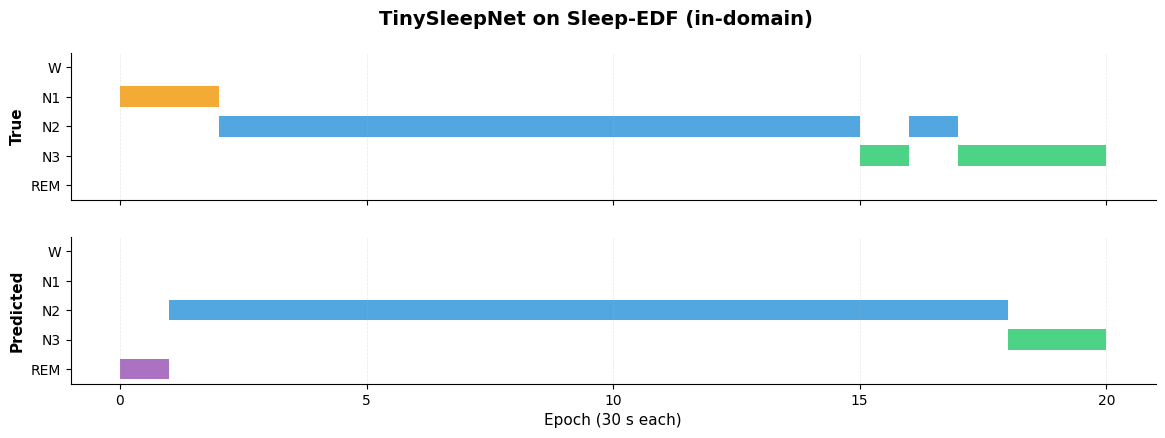

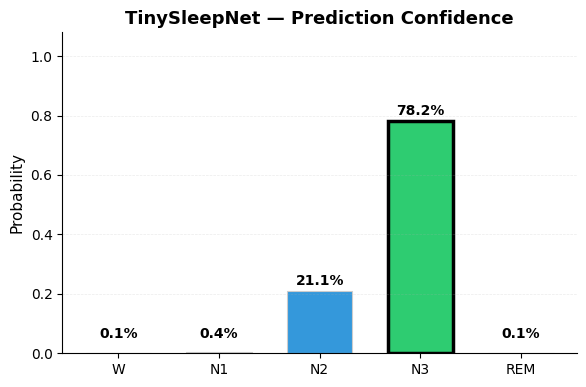

In [6]:
from physioex.models import load_from_pretrained

tiny = load_from_pretrained("tinysleepnet-supratak", device=device, verbose=True)

# Forward pass on L=20 epochs: (1, L, C=1, T=3000)
x_raw = sample_raw["signals"][eeg_ch].unsqueeze(0).unsqueeze(2).to(device)

with torch.no_grad():
    logits = tiny(x_raw)
    probs_raw = logits.softmax(-1).squeeze(0).cpu()
    preds = probs_raw.argmax(-1)

# Hypnogram: true vs predicted
plot_hypnogram(sample_raw["labels"], pred_labels=preds,
               title="TinySleepNet on Sleep-EDF (in-domain)")

# Select the highest-confidence correctly-predicted N3 epoch
n3_mask = (sample_raw["labels"] == 3) & (preds == 3)
n3_conf = probs_raw[:, 3] * n3_mask.float()
epoch_idx_tiny = n3_conf.argmax().item()
pred_label_tiny = preds[epoch_idx_tiny].item()
print(f"\nTarget epoch {epoch_idx_tiny}: true=N3, predicted={STAGE_NAMES[pred_label_tiny]}, "
      f"confidence={probs_raw[epoch_idx_tiny, pred_label_tiny]:.1%}")

# Single-epoch probability distribution
plot_pred_barplot(probs_raw[epoch_idx_tiny], true_label=3, model_name="TinySleepNet")
_

### SeqSleepNet — Spectrogram → Sleep Stages

**Per-epoch feature extraction** (Filterbank + BiLSTM + Attention):  
- Learnable filterbank: (29 time bins × 129 freq bins) → (29 × 32 channels)  
- Bidirectional LSTM (32 → 128, 4 layers) + attention pooling → 128-dim per epoch

**Sequence context** (RNN):  
- Bidirectional GRU (128 → 128, 4 layers) captures temporal transitions

**Classification**: Linear(128 → 5) per epoch

The filterbank **learns** which frequency combinations are most discriminative for sleep staging.

*Reference: Phan et al., 2019 — SeqSleepNet*

Model:     seqsleepnet-phan
Class:     physioex.models.seqsleepnet:SeqSleepNet
Params:    659,205
Reference: Phan et al. 2019 - SeqSleepNet: End-to-End Hierarchical Recurrent Neural Network for Sequence-to-Sequence Automatic Sleep Staging
Trained on: mass, channels=['EEG'], L=20, epochs=10

Accuracy: 0.8515, F1: 0.7977, Kappa: 0.7869

Target epoch 8: true=N3, predicted=N3, confidence=99.4%


/mnt/nfs/guido/home/dev/physioex/lectures/2026-06-24_ugent_xai/util.py:164: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.94])


''

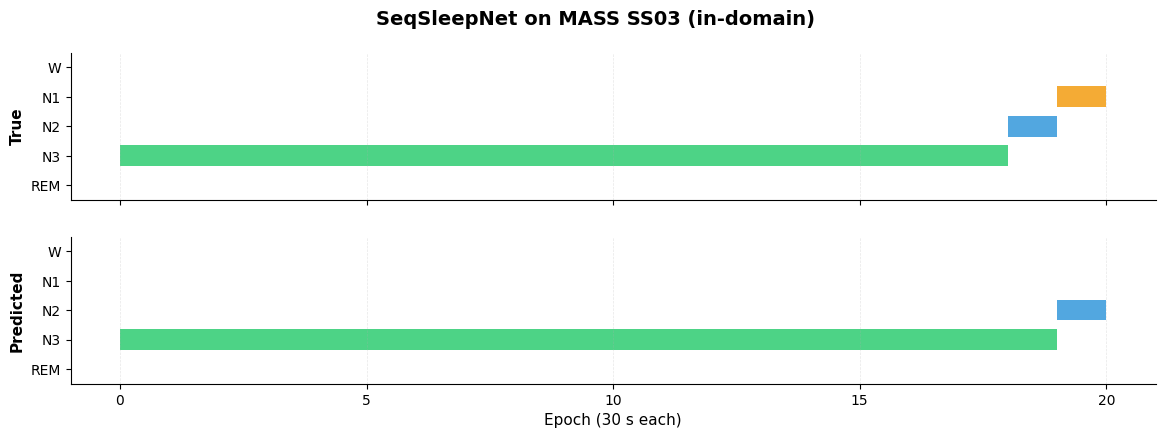

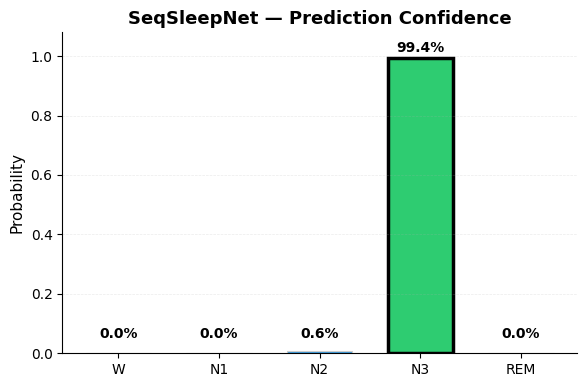

In [7]:
seq = load_from_pretrained("seqsleepnet-phan", device=device, verbose=True)

# Forward pass on L=20 epochs: (1, L, C=1, T=29, F=129)
x_spec = sample_spec["signals"][eeg_ch_spec].unsqueeze(0).unsqueeze(2).to(device)

with torch.no_grad():
    logits = seq(x_spec)
    probs_spec = logits.softmax(-1).squeeze(0).cpu()
    preds_seq = probs_spec.argmax(-1)

# Hypnogram: true vs predicted
plot_hypnogram(sample_spec["labels"], pred_labels=preds_seq,
               title="SeqSleepNet on MASS SS03 (in-domain)")

# Select the highest-confidence correctly-predicted N3 epoch
n3_mask_s = (sample_spec["labels"] == 3) & (preds_seq == 3)
n3_conf_s = probs_spec[:, 3] * n3_mask_s.float()
epoch_idx_seq = n3_conf_s.argmax().item()
pred_label_seq = preds_seq[epoch_idx_seq].item()
print(f"\nTarget epoch {epoch_idx_seq}: true=N3, predicted={STAGE_NAMES[pred_label_seq]}, "
      f"confidence={probs_spec[epoch_idx_seq, pred_label_seq]:.1%}")

# Single-epoch probability distribution
plot_pred_barplot(probs_spec[epoch_idx_seq], true_label=3, model_name="SeqSleepNet")
_

Both models correctly classify the target N3 epoch — TinySleepNet with ~78% confidence, SeqSleepNet with ~99%.

But **why** do they predict N3? What input features drive this decision? We need **explainability methods** to answer this.

## Integrated Gradients

### Intuition

Imagine a path from **silence** (all zeros) to the **actual signal**:

1. Start with a blank input (baseline) — the model has no evidence for any class
2. Gradually "fade in" the real signal along a straight line
3. At each point, measure: *how much does the model's N3 confidence change if I increase this feature slightly?*
4. **Accumulate** these sensitivities across the entire path

The result is an **attribution map** with the same shape as the input — each element tells you how much that feature contributed to the prediction.

- **Positive** attribution → pushes the prediction **toward** N3
- **Negative** attribution → pushes **away** from N3

Key property: **Completeness** — the attributions sum exactly to `F(x) - F(baseline)`, so nothing is lost or double-counted.

### Formulation

For input $x$, baseline $x'$ (silence), and model score function $F$:

$$\text{IG}_i(x) \;=\; \bigl(x_i - x'_i\bigr) \times \int_0^1 \frac{\partial F}{\partial x_i}\!\left(x' + \alpha \cdot (x - x')\right) d\alpha$$

In practice, the integral is approximated by a **Riemann sum** over $N$ uniformly-spaced $\alpha$ values (we use $N = 64$):

$$\text{IG}_i(x) \approx \bigl(x_i - x'_i\bigr) \times \frac{1}{N} \sum_{k=1}^{N} \frac{\partial F}{\partial x_i}\!\left(x' + \frac{k}{N}(x - x')\right)$$

**Why IG over vanilla gradients?** Vanilla gradients only look at the local slope at $x$, which can be noisy and misleading. IG integrates along the full path, satisfying two axioms (Sundararajan et al., ICML 2017):

- **Sensitivity**: if a feature matters, it gets nonzero attribution
- **Implementation invariance**: functionally equivalent models give identical attributions

Epoch 18: true=N3, predicted=N3, confidence=78.2%


/mnt/nfs/guido/home/dev/physioex/lectures/2026-06-24_ugent_xai/util.py:208: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


''

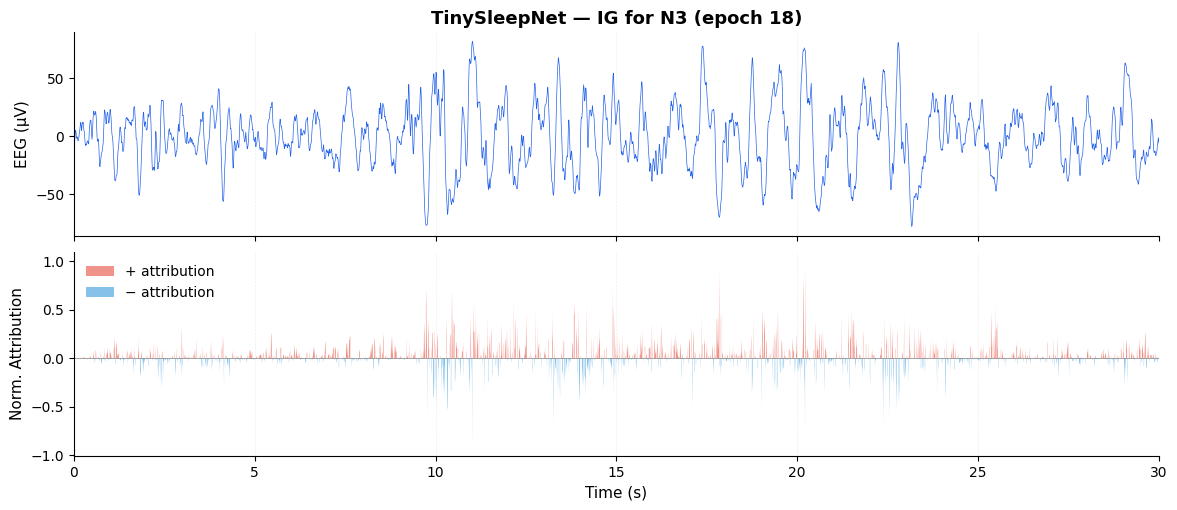

In [8]:
from physioex.explain.posthoc import IntegratedGradients

# --- IG on TinySleepNet (raw N3 epoch) ---
print(f"Epoch {epoch_idx_tiny}: true=N3, predicted={STAGE_NAMES[pred_label_tiny]}, "
      f"confidence={probs_raw[epoch_idx_tiny, pred_label_tiny]:.1%}")

def tiny_score(x_epoch):
    """x_epoch: (B, T) -> (B,) N3 score."""
    x = x_epoch.unsqueeze(1).unsqueeze(1)  # (B, 1, 1, T)
    logits = tiny(x)
    return logits[:, 0, :].softmax(-1)[:, pred_label_tiny]

ig = IntegratedGradients(f=tiny_score, steps=64, expects_batch=True)

torch.backends.cudnn.enabled = False  # allow RNN backward in eval mode
x_epoch = sample_raw["signals"][eeg_ch][epoch_idx_tiny].unsqueeze(0).to(device)
attr = ig(x_epoch)
torch.backends.cudnn.enabled = True

plot_ig_raw(x_epoch, attr, pred_label_tiny, epoch_idx_tiny, model_name="TinySleepNet")
_

### Can we validate this explanation?

The attribution shows peaks at specific time segments — the model focuses on **slow, high-amplitude oscillations**, consistent with delta waves.

But there's a problem: in the **time domain**, we cannot directly confirm that these peaks correspond to 0.5–4 Hz activity. The raw waveform shows *where* in time the model looks, but not *what frequency* it responds to.

To truly validate, we would need to filter the signal into frequency bands and re-attribute — but that changes the input space. This is a **fundamental limitation** of post-hoc attribution on raw time-domain signals.

Epoch 8: true=N3, predicted=N3, confidence=99.4%
Noise-floor baseline: -34.90 dB (mean of bins > 40 Hz)


/mnt/nfs/guido/home/dev/physioex/lectures/2026-06-24_ugent_xai/util.py:261: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


''

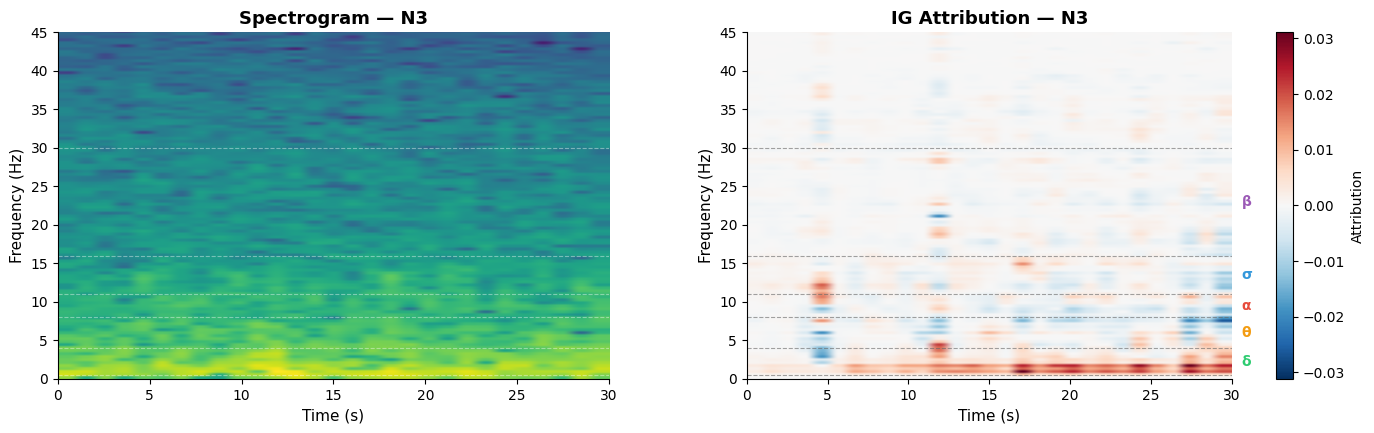

In [9]:
# --- IG on SeqSleepNet (spectrogram N3 epoch) ---
print(f"Epoch {epoch_idx_seq}: true=N3, predicted={STAGE_NAMES[pred_label_seq]}, "
      f"confidence={probs_spec[epoch_idx_seq, pred_label_seq]:.1%}")

def seq_score(x_epoch):
    """x_epoch: (B, T, F) -> (B,) N3 score."""
    x = x_epoch.unsqueeze(1).unsqueeze(1)  # (B, 1, 1, T, F)
    logits = seq(x)
    return logits[:, 0, :].softmax(-1)[:, pred_label_seq]

ig_seq = IntegratedGradients(f=seq_score, steps=64, expects_batch=True)

torch.backends.cudnn.enabled = False
x_epoch_s = sample_spec["signals"][eeg_ch_spec][epoch_idx_seq].unsqueeze(0).to(device)

# Baseline = noise floor: mean power above 40 Hz (outside the 0.3-40 Hz bandpass)
# In the spectrogram, 0 dB ≠ silence — it means unit power. The true "no signal"
# is the noise floor, which we estimate from frequencies the bandpass filter rejects.
n_freq = x_epoch_s.shape[-1]  # 129 bins, 0-50 Hz
bin_40hz = int(40.0 / 50.0 * n_freq)
noise_floor = x_epoch_s[..., bin_40hz:].mean()
baseline_s = torch.full_like(x_epoch_s, noise_floor.item())
print(f"Noise-floor baseline: {noise_floor.item():.2f} dB (mean of bins > 40 Hz)")

attr_s = ig_seq(x_epoch_s, baseline=baseline_s)
torch.backends.cudnn.enabled = True

plot_ig_spectrogram(x_epoch_s, attr_s,
                    sample_spec["labels"][epoch_idx_seq].item(),
                    pred_label_seq, model_name="SeqSleepNet")


_

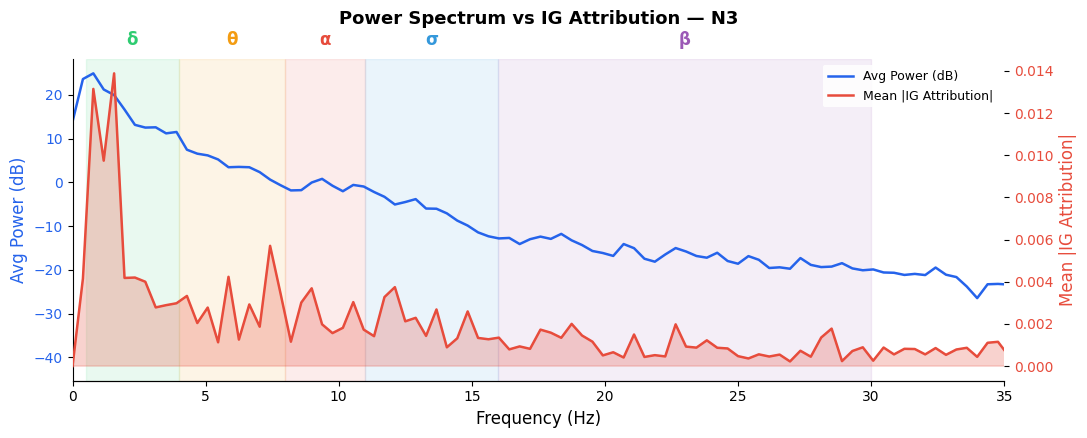

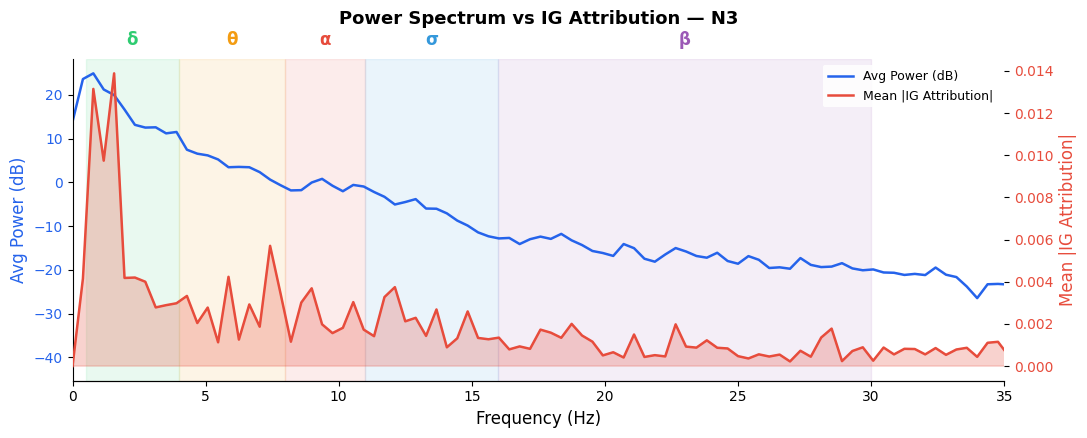

In [10]:
# Overlay: attribution importance vs power spectrum per frequency
plot_attribution_vs_psd(x_epoch_s, attr_s, stage_name="N3")

### Validating the explanation

Now the attribution lives in the **time-frequency domain**. We can directly see *which frequencies* the model relies on.

Compare the IG attribution (right panel) with the power spectrum we computed earlier: the model's positive attributions concentrate in the **lowest frequency bins (0–4 Hz)** — the delta band. This matches exactly the dominant frequency content of N3 that we observed in the PSD.

Unlike the raw-signal case, here we can **validate the explanation**: the model correctly focuses on the physiologically meaningful frequency band for N3 classification. This is a strength of working in interpretable feature spaces — post-hoc explanations become more **actionable** when input dimensions have clear physical meaning.

### The Baseline Choice

For **TinySleepNet** (raw signal), `baseline = 0` is natural — zero amplitude means silence.

For **SeqSleepNet** (spectrogram in dB), `baseline = 0` would mean 0 dB = unit power, **not** silence. Instead, we use the **noise floor**: the mean power above 40 Hz, where the bandpass filter (0.3–40 Hz) has already removed all real signal. This represents "no informative content" in the spectrogram domain.

IG then asks: *"compared to pure noise, what in this spectrogram makes the model say N3?"*

Other baseline alternatives:
- **Random noise**: *"compared to noise, what is structured enough to be N3?"*
- **Mean spectrogram**: *"compared to an average epoch, what is distinctive here?"*
- **Contrastive** (e.g., a Wake epoch): *"what makes this N3 rather than Wake?"*

The choice changes the **question**. The **Completeness axiom** guarantees:

$$\sum_i \text{IG}_i(x) = F(x) - F(x')$$

With a noise-floor baseline, the attributions explain what the model sees **above the noise**.

## Wrap-Up

In this session we:

1. Examined N3 (deep sleep) in two EEG representations and confirmed **delta-band dominance** via power spectral analysis
2. Ran two pretrained **seq-to-seq** models (TinySleepNet on raw EEG, SeqSleepNet on spectrograms) — both correctly classify N3
3. Applied **Integrated Gradients** to explain what drives each model's N3 prediction
4. Found that **spectrogram-domain attributions are directly interpretable** in terms of frequency bands, while raw-domain attributions are harder to validate

**Key insight**: the choice of input representation affects not just model performance, but also **how interpretable the explanations are**.

---

- **GitHub**: [github.com/guidogagl/physioex](https://github.com/guidogagl/physioex)
- **PyPI**: `pip install physioex`
- **Models**: [huggingface.co/4rooms/physioex](https://huggingface.co/4rooms/physioex)